Code below will read through mesh & field that are saved from running the code and use MFEM commands to plot. 

In [1]:
%pip install -q ipympl ipywidgets

# restart the kernel after pip install

Note: you may need to restart the kernel to use updated packages.


In [2]:
import mfem.ser as mfem
import matplotlib.pylab as plt
import math
%matplotlib widget

from scipy.spatial import Delaunay
import numpy as np
import plotly.graph_objects as go

from matplotlib import cm
from matplotlib.colors import ListedColormap


In [15]:
mesh = mfem.Mesh()
# mesh.Load("outputs/Results/20251008_094134__nsteps=10000__mesh=Mesh_40x60_F00/pmesh.000000")
# x = mfem.GridFunction(mesh,"outputs/Results/20251008_094134__nsteps=10000__mesh=Mesh_40x60_F00/CnP_final.000000")
mesh.Load("outputs/Results/20251008_094134__nsteps=10000__mesh=Mesh_40x60_F00/pmesh.000000")
x = mfem.GridFunction(mesh,"outputs/Results/20251009_150223__nsteps=100000__mesh=Mesh_40x60_F00/CnP_final.000000")

# mesh.Load("meshCH")
# x = mfem.GridFunction(mesh,"CnCH")

vertices = mesh.GetVertexArray()
ar = np.array(vertices)
X = ar[:,0]
Y = ar[:,1]
Z = x.GetDataArray()

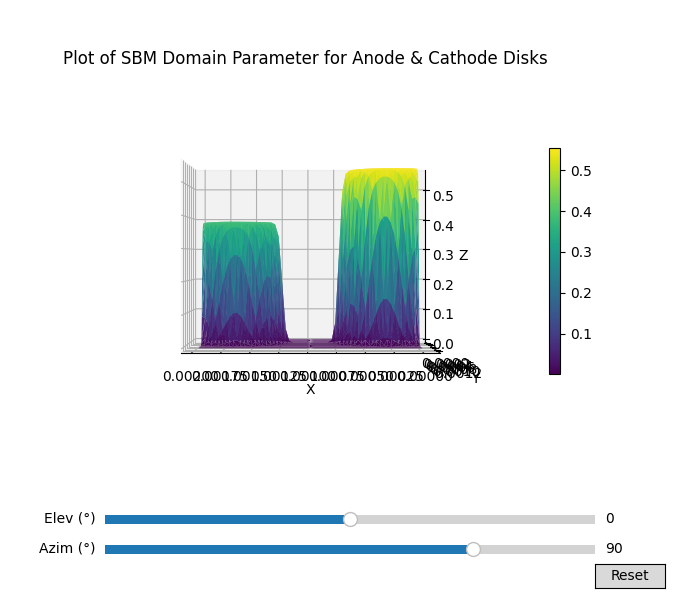

In [4]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# draw your surface
surf = ax.plot_trisurf(X, Y, Z, cmap='viridis')  # keep as-is if your data are unstructured
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Plot of SBM Domain Parameter for Anode & Cathode Disks")

# ✅ add colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)

# start from a "front" view (looking along +y)
start_elev, start_azim = 0, 90
ax.view_init(elev=start_elev, azim=start_azim)

# layout for sliders
plt.subplots_adjust(bottom=0.25)  # leave space under the plot

# slider axes: [left, bottom, width, height] in figure coords
ax_elev = plt.axes([0.15, 0.12, 0.7, 0.03])
ax_azim = plt.axes([0.15, 0.07, 0.7, 0.03])

# sliders
s_elev = Slider(ax_elev, 'Elev (°)', -90.0, 90.0, valinit=start_elev)
s_azim = Slider(ax_azim, 'Azim (°)', -180.0, 180.0, valinit=start_azim)

def update_view(val=None):
    ax.view_init(elev=s_elev.val, azim=s_azim.val)
    fig.canvas.draw_idle()

s_elev.on_changed(update_view)
s_azim.on_changed(update_view)

# reset button
ax_reset = plt.axes([0.85, 0.02, 0.1, 0.04])
b_reset = Button(ax_reset, 'Reset')

def reset(event):
    s_elev.reset()
    s_azim.reset()
b_reset.on_clicked(reset)

plt.show()


Code below will read through the mesh & field that are saved from running the code.
This method parses through the documents and does not utilize MFEM. 

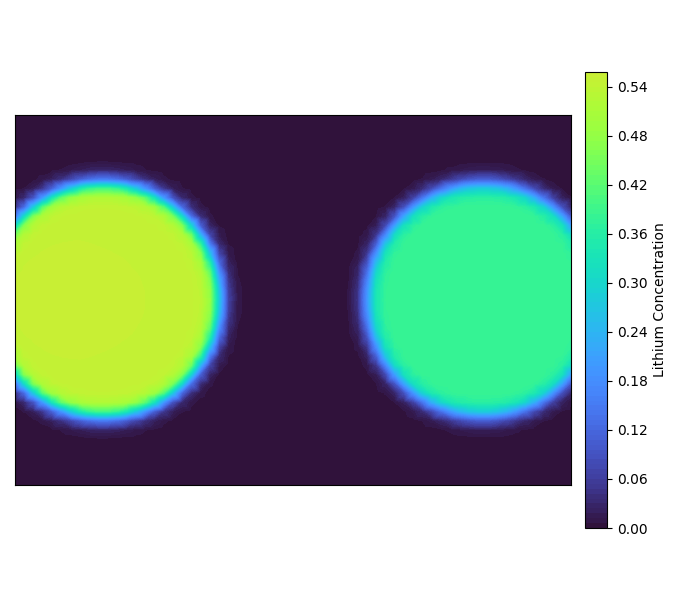

In [16]:


# --- assume X, Y, Z are your data arrays ---
# X, Y: 1D arrays of points
# Z:    1D array of values at each (X, Y)

from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(7, 6))

# Filled contour or smooth color map for unstructured data
cntr = ax.tricontourf(X, Y, Z, levels=100, cmap='turbo', vmin=0, vmax=1)

# Add colorbar
cbar = fig.colorbar(cntr, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Lithium Concentration")
# cbar.set_ticks(np.linspace(0, 1, 6))  # optional: nice tick spacing


# Axis labels and title
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
ax.set_xticks([])
ax.set_yticks([])
# ax.set_title("Anode & Cathode Disks")

# Force 1:1 aspect ratio for correct geometry
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()



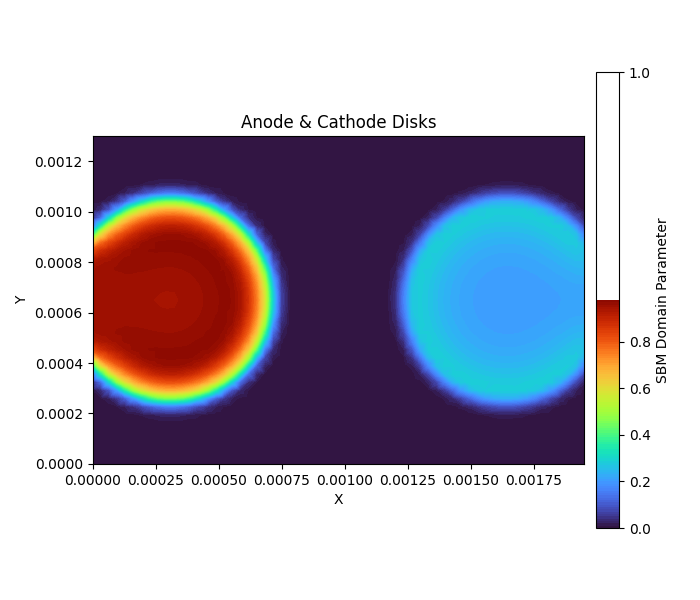

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(7, 6))

# Explicit normalization for 0–1 range
norm = Normalize(vmin=0, vmax=1)

# Contour plot with fixed normalization
cntr = ax.tricontourf(X, Y, Z, levels=100, cmap='turbo', norm=norm)

# Colorbar that respects full 0–1 normalization
cbar = fig.colorbar(cntr, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("SBM Domain Parameter")
cbar.set_ticks(np.linspace(0, 1, 6))  # evenly spaced ticks
cntr.set_clim(0, 1)  # ensures colorbar fills fully

# Axis labels and title
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Anode & Cathode Disks")

# Force 1:1 aspect ratio for proper geometry
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

# ----- helpers -----
def _next_data_line(lines, i):
    """Return index of next non-empty, non-comment line."""
    n = len(lines)
    while i < n:
        s = lines[i].strip()
        if s and not s.startswith("#"):
            return i
        i += 1
    return i

def parse_mfem_mesh(path):
    """
    Parse MFEM ASCII mesh v1.0 and return (dim, vertices[N, dim]).
    Robust to line breaks in vertex coordinates.
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    i = 0
    # find 'dimension'
    while i < len(lines) and "dimension" not in lines[i].lower():
        i += 1
    if i == len(lines):
        raise ValueError("Could not find 'dimension' in mesh file.")
    i = _next_data_line(lines, i+1)
    dim = int(float(lines[i].strip())); i += 1

    # find 'vertices'
    while i < len(lines) and "vertices" not in lines[i].lower():
        i += 1
    if i == len(lines):
        raise ValueError("Could not find 'vertices' in mesh file.")
    i = _next_data_line(lines, i+1)
    nv = int(float(lines[i].strip())); i += 1

    # some files include a vdim line; if not, assume vdim == dim
    i = _next_data_line(lines, i)
    vdim = None
    try:
        possible = int(float(lines[i].strip().split()[0]))
        if 1 <= possible <= 3:
            vdim = possible
            i += 1
    except Exception:
        pass
    if vdim is None:
        vdim = dim

    # read nv vertices with vdim coords (allow coordinates to span lines)
    verts, acc, read_count = [], [], 0
    while read_count < nv:
        s = lines[i].strip(); i += 1
        if not s or s.startswith("#"):
            continue
        for t in s.split():
            try:
                acc.append(float(t))
            except Exception:
                pass
        while len(acc) >= vdim and read_count < nv:
            verts.append(acc[:vdim])
            acc = acc[vdim:]
            read_count += 1

    V = np.array(verts, dtype=float)
    if V.shape != (nv, vdim):
        raise ValueError(f"Vertex array has wrong shape {V.shape}, expected ({nv},{vdim})")
    return dim, V

def parse_mfem_gridfunction(path):
    """
    Parse MFEM ASCII scalar GridFunction to a 1D numpy array.
    (Assumes header lines with 'FiniteElementSpace', 'Ordering', etc.)
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    # find "Ordering" then next blank line; data follows
    i = 0
    while i < len(lines):
        if lines[i].strip().lower().startswith("ordering"):
            i += 1
            while i < len(lines) and lines[i].strip() != "":
                i += 1
            break
        i += 1
    data = []
    for j in range(i, len(lines)):
        s = lines[j].strip()
        if not s or s.startswith("#") or s == "...":
            continue
        for token in s.split():
            try:
                data.append(float(token))
            except ValueError:
                pass
    return np.array(data, dtype=float)


In [ ]:
# Update these paths if your files are elsewhere
# mesh_path = "inputs/pmesh.000000"
# field_path = "inputs/CnCH.000000"

mesh_path = "outputs/Results/20250820_170500__nsteps=6__mesh=disk_Mesh_80x80x6/pmesh.000000"
field_path = "outputs/Results/20250820_170500__nsteps=6__mesh=disk_Mesh_80x80x6/AvP.000000"



In [ ]:
dim, V = parse_mfem_mesh(mesh_path)
vals = parse_mfem_gridfunction(field_path)

nv = V.shape[0]
if vals.size < nv:
    raise ValueError(f"GridFunction has {vals.size} values, mesh has {nv} vertices.")
nodal_vals = vals[:nv]          # assumes H1 P1 nodal ordering

print(f"mesh dimension: {dim}")
print(f"num vertices:   {nv}")
print(f"value range:    {nodal_vals.min():.6g} .. {nodal_vals.max():.6g}")
print(f"mean:           {nodal_vals.mean():.6g}")


In [ ]:
if dim == 3:
    z = V[:,2]
    zmid = float(np.median(z))
    tol = 0.05 * (z.max() - z.min() if z.max() > z.min() else 1.0)  # 5% thickness
    mask = np.abs(z - zmid) <= tol

    if np.count_nonzero(mask) > 50:
        fig2 = plt.figure(figsize=(6,6))
        ax2 = fig2.add_subplot(111)
        sc2 = ax2.scatter(V[mask,0], V[mask,1], c=nodal_vals[mask], s=6)
        ax2.set_aspect('equal', adjustable='box')
        ax2.set_title(f"mid slice")
        ax2.set_xlabel("x"); ax2.set_ylabel("y")
        plt.colorbar(sc2, ax=ax2)
        plt.show()
    else:
        print("Not enough points near median z for a mid-Z slice.")



In [ ]:
if dim == 3:
    z = V[:, 2]
    zmax = float(z.max())

    # Pick a thin layer near the top: either 5% of z-range OR one z-layer if the mesh is layered.
    # Method A (simple): fixed thickness as a fraction of the z-range
    tol = 0.05 * (z.max() - z.min() if z.max() > z.min() else 1.0)

    # Optional Method B (layer-aware): use ~1.5× the smallest z-spacing seen
    # uniq = np.unique(np.round(z, 12))           # round to merge tiny fp jitter
    # dz = np.diff(np.sort(uniq))
    # if dz.size > 0:
    #     tol = max(tol, 1.5 * dz.min())

    mask = (z >= zmax - tol)

    if np.count_nonzero(mask) > 50:
        fig2 = plt.figure(figsize=(6, 6))
        ax2 = fig2.add_subplot(111)
        sc2 = ax2.scatter(V[mask, 0], V[mask, 1], c=nodal_vals[mask], s=6)
        ax2.set_aspect('equal', adjustable='box')
        ax2.set_title("Top slice (z ≈ z_max)")
        ax2.set_xlabel("x"); ax2.set_ylabel("y")
        plt.colorbar(sc2, ax=ax2)
        plt.show()
    else:
        print("Not enough points near the top surface for a slice.")


In [ ]:
if dim == 2:
    # V: (N,2) array of node coords, nodal_vals: (N,) values at nodes
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)

    sc = ax.scatter(V[:, 0], V[:, 1], c=nodal_vals, s=6)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title("2D field")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(sc, ax=ax)
    plt.show()






